In [1]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import uproot
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

In [3]:
parquet_file = "28_April_2026/Background_Data/Counts_50000_5min_10ns_csv_grouping2.parquet"   # change this
duration_s = 75.0
file_label = parquet_file
batch_size = 1_000_000

pf = pq.ParquetFile(parquet_file)

In [5]:
for batch in pf.iter_batches(
    batch_size=1_000_000,
    columns=["Board_Id", "CH_Id"]
):
    df_chunk = batch.to_pandas()

In [6]:
df_chunk

,Board_Id,CH_Id
0,2,2
1,2,57
2,2,29
3,0,44
4,2,60
...,...,...
788590,3,53
788591,3,35
788592,3,24
788593,3,60


In [7]:
import ROOT

print(ROOT.gROOT.GetVersion())

Welcome to JupyROOT 6.26/10
6.26/10


In [15]:
!ls ../ROOT_files/28_April_2026/Background_Data/Counts_50000_5min_10ns_csv.root 

Counts_50000_5min_10ns_csv_grouping2.root
Counts_50000_5min_10ns_csv.root
Counts_50000_5min_2ns_csv_grouping2.root


In [8]:
f = ROOT.TFile.Open("../ROOT_files/3_May_2026/Trigger_testing/Brd1-HVON-OnlyTopChannelsUnmasked/Counts_50000_5min_10ns_csv.root")
f.ls()

TFile**		../ROOT_files/3_May_2026/Trigger_testing/Brd1-HVON-OnlyTopChannelsUnmasked/Counts_50000_5min_10ns_csv.root	
 TFile*		../ROOT_files/3_May_2026/Trigger_testing/Brd1-HVON-OnlyTopChannelsUnmasked/Counts_50000_5min_10ns_csv.root	
  KEY: TTree	Events;1	Events grouped by abs time (external merge) + Ring


In [10]:
tree = f.Get("Events")

In [11]:
tree.GetEntries()

2094789

In [16]:
! ls -l ../ROOT_files/1_May_2026/Trigger_testing/


## TimingModeTesting-Board1TopWithInsulationOn3L3R-HVOFF
## TimingModeTesting-Board1TopWithInsulationSwitched-HVOFF
## TimingModeTesting-Board1Top-Aluminum5R-HVOFF    

total 24
drwxrwxr-x 2 pratyush pratyush 4096 May  1 15:50 TimingModeTesting-Board1Top-250Thresh-HVOFF
drwxrwxr-x 2 pratyush pratyush 4096 May  1 17:09 TimingModeTesting-Board1Top-Aluminum5R-HVOFF
drwxrwxr-x 2 pratyush pratyush 4096 May  1 15:35 TimingModeTesting-Board1Top-HVOFF
drwxrwxr-x 2 pratyush pratyush 4096 May  1 15:32 TimingModeTesting-Board1Top-HVON
drwxrwxr-x 2 pratyush pratyush 4096 May  1 16:28 TimingModeTesting-Board1TopWithInsulationOn3L3R-HVOFF
drwxrwxr-x 2 pratyush pratyush 4096 May  1 16:44 TimingModeTesting-Board1TopWithInsulationSwitched-HVOFF


In [15]:
60*5*25e-6*100

0.7500000000000001

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
from collections import Counter

def format_ring_label(ring):
    if ring <= 14:
        return f"Ring {ring}R"
    else:
        return f"Ring {ring - 14}L"

# -----------------------------
# 1. Ring map
# -----------------------------
ring_map = {
    0: [
        [47, 45, 43, 41, 46, 44, 42, 40],
        [63, 61, 59, 57, 62, 60, 58, 56],
        [39, 37, 35, 33, 38, 36, 34, 32],
        [55, 53, 51, 49, 54, 52, 50, 48],
    ],
    1: [
        [15, 14, 13, 12, 11, 10, 9, 8],
        [31, 30, 29, 28, 27, 26, 25, 24],
        [47, 46, 45, 44, 43, 42, 41, 40],
        [63, 62, 61, 60, 59, 58, 57, 56],
        [7, 6, 5, 4, 3, 2, 1, 0],
        [23, 22, 21, 20, 19, 18, 17, 16],
        [39, 38, 37, 36, 35, 34, 33, 32],
        [55, 54, 53, 52, 51, 50, 49, 48],
    ],
    2: [
        [15, 14, 13, 12, 11, 10, 9, 8],
        [31, 30, 29, 28, 27, 26, 25, 24],
        [47, 46, 45, 44, 43, 42, 41, 40],
        [63, 62, 61, 60, 59, 58, 57, 56],
        [7, 6, 5, 4, 3, 2, 1, 0],
        [23, 22, 21, 20, 19, 18, 17, 16],
        [39, 38, 37, 36, 35, 34, 33, 32],
        [55, 54, 53, 52, 51, 50, 49, 48],
    ],
    3: [
        [15, 14, 13, 12, 11, 10, 9, 8],
        [31, 30, 29, 28, 27, 26, 25, 24],
        [47, 46, 45, 44, 43, 42, 41, 40],
        [63, 62, 61, 60, 59, 58, 57, 56],
        [7, 6, 5, 4, 3, 2, 1, 0],
        [23, 22, 21, 20, 19, 18, 17, 16],
        [39, 38, 37, 36, 35, 34, 33, 32],
        [55, 54, 53, 52, 51, 50, 49, 48],
    ]
}

ring_counter_assignment = np.array([
    1, 2, 15, 16, 3, 4, 5, 6,
    17, 18, 19, 20, 7, 8, 9, 10,
    21, 22, 23, 24, 11, 12, 13, 14,
    25, 26, 27, 28
])

board_ring_labels = {}
global_ring_idx = 0

for board_id, ring_lists in ring_map.items():
    board_ring_labels[board_id] = []
    for ring_list in ring_lists:
        ring_num = int(ring_counter_assignment[global_ring_idx])
        board_ring_labels[board_id].append(ring_num)
        global_ring_idx += 1


# -----------------------------
# 2. Chunked ROOT reading
# -----------------------------
root_file = "../ROOT_files//6_May_2026/Brd0-Brd1-Brd2-HVOFF-Brd0Closed/Counts_50000_5min_10ns_csv.root"
tree_name = "Events"

duration_s = 60*5*24e-6*100
file_label = root_file
step_size = "100 MB"

# Inspect available branches
with uproot.open(root_file) as f:
    tree = f[tree_name]
    branches = tree.keys()
    print("Branches:", branches)

board_col="Board_Id"
needed_cols = [board_col, "CH_Id", "ToA_LSB"]

counts_by_board_ch = Counter()

for arrays in uproot.iterate(
    f"{root_file}:{tree_name}",
    needed_cols,
    library="pd",
    step_size=step_size,
):
    # -----------------------------
    # Apply ToA cut
    # -----------------------------
    arrays = arrays[arrays["ToA_LSB"] > 1000]

    # Skip empty chunks (important for speed)
    if arrays.empty:
        continue

    grouped = arrays.groupby([board_col, "CH_Id"]).size()

    for key, val in grouped.items():
        counts_by_board_ch[(int(key[0]), int(key[1]))] += int(val)

    del arrays, grouped

print("Finished counting.")
print("Unique board-channel pairs:", len(counts_by_board_ch))

Branches: ['TStamp_us', 'Board_Id', 'Num_Hits', 'CH_Id', 'DataType', 'ToA_LSB', 'ToT_LSB', 't_abs_us', 'Ring', 'Event_Id']
Finished counting.
Unique board-channel pairs: 153


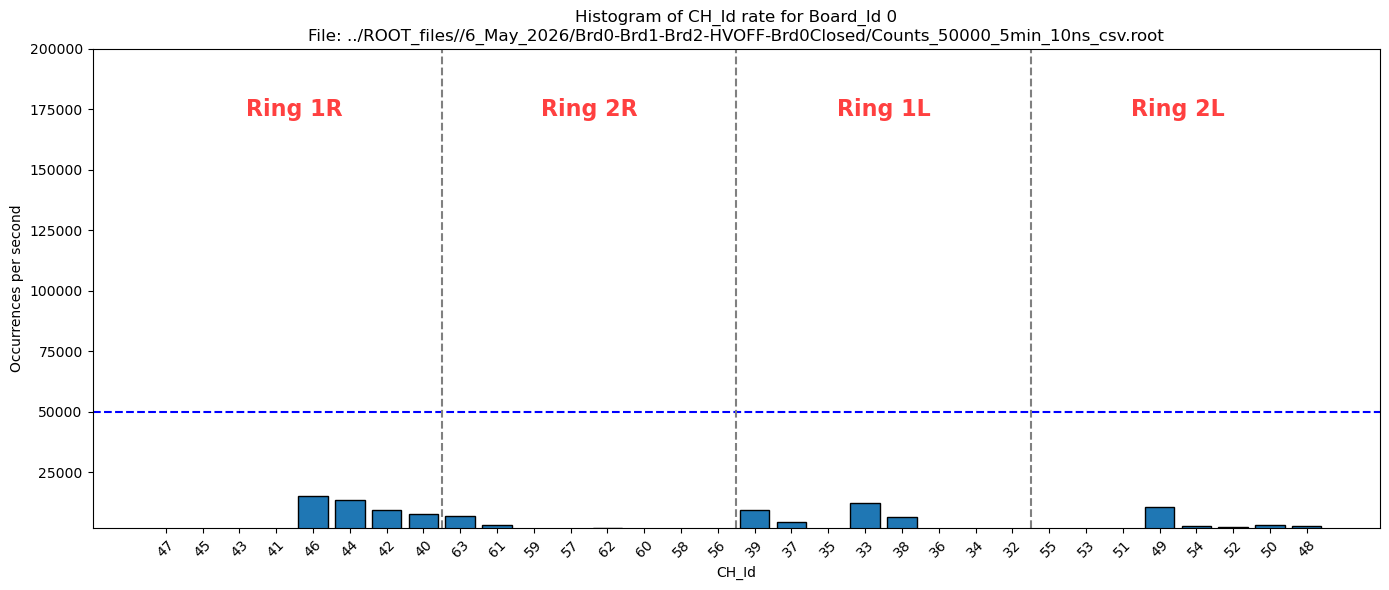

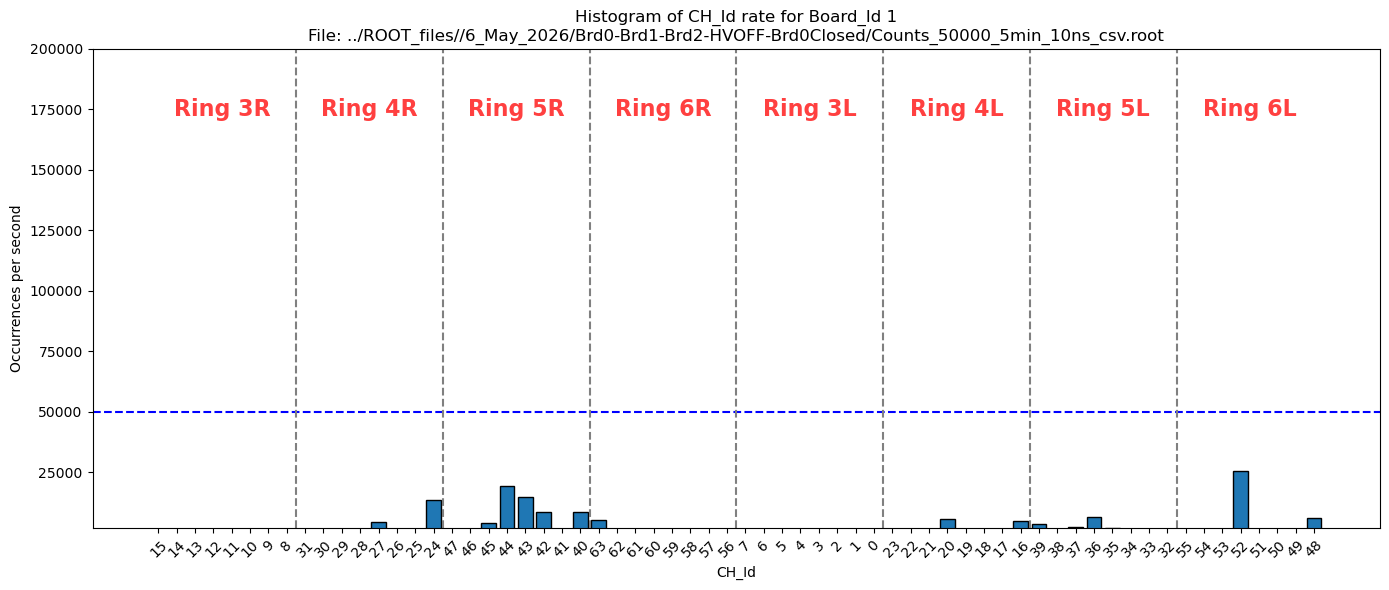

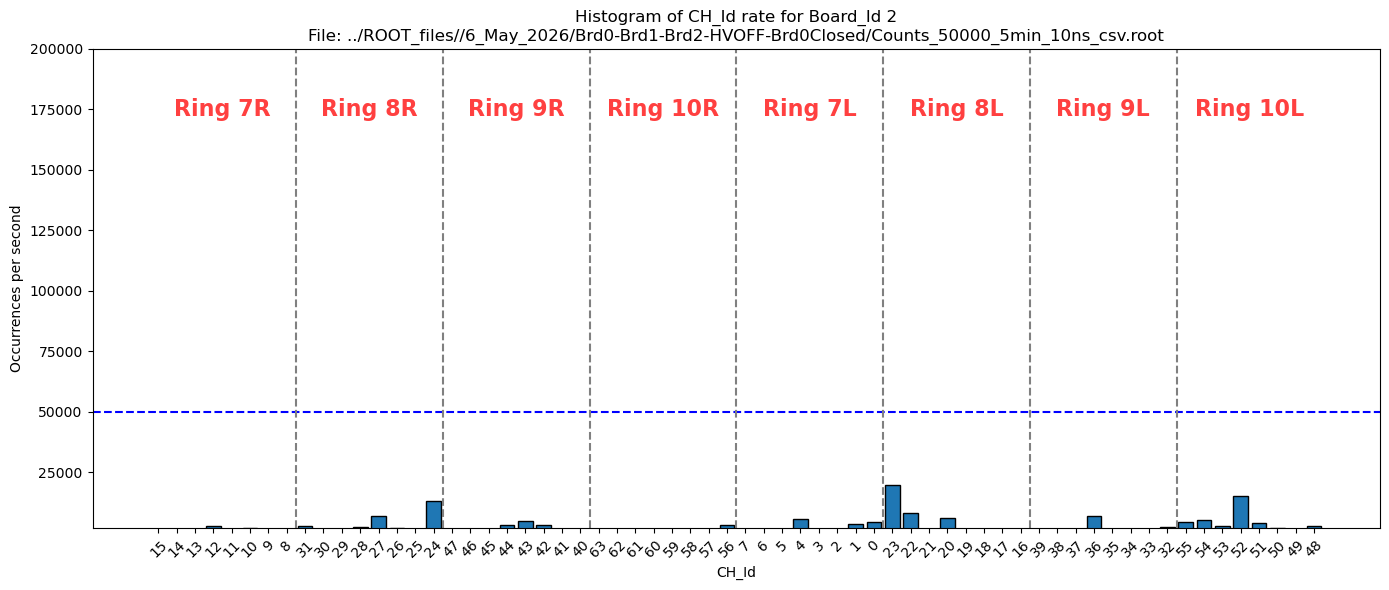

In [21]:
# -----------------------------
# 3. Plot per board
# -----------------------------
board_ids = sorted({b for (b, ch) in counts_by_board_ch.keys()})

global_max_counts = max(counts_by_board_ch.values()) if counts_by_board_ch else 0
global_max_rate = global_max_counts / duration_s if duration_s > 0 else 1.0
y_upper = global_max_rate * 1.05 if global_max_rate > 0 else 1.0

for board_id in board_ids:
    if board_id not in ring_map:
        print(f"Skipping Board_Id {board_id}: not in ring_map")
        continue

    channel_order = [ch for ring in ring_map[board_id] for ch in ring]

    counts = np.array(
        [counts_by_board_ch.get((board_id, ch), 0) for ch in channel_order],
        dtype=float
    )

    rates = counts / duration_s

    positive_rates = rates[rates > 0]
    min_positive = positive_rates.min() if len(positive_rates) > 0 else 1.0
    safe_min = min_positive * 0.5

    rates_for_plot = np.where(rates > 0, rates, safe_min)

    x = np.arange(len(channel_order))

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(x, rates_for_plot, align="center", edgecolor="black")

    ax.set_xlabel("CH_Id")
    ax.set_ylabel("Occurrences per second")
    ax.axhline(5e4, color="blue", linestyle="dashed")
    ax.set_title(
        f"Histogram of CH_Id rate for Board_Id {board_id}\n"
        f"File: {file_label}"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(channel_order, rotation=45)

    #y_low = max(safe_min, 1e-2)
    #y_high = max(y_upper, y_low * 10)
    ax.set_ylim(2e3, 20e4)

    n_rings = len(ring_map[board_id])
    for i in range(1, n_rings):
        ax.axvline(i * 8 - 0.5, color="gray", linestyle="dashed")

    #y_label_pos = y_low * (y_high / y_low) ** 0.9
    y_label_pos = 1.75e5

    for i, ring_num in enumerate(board_ring_labels[board_id]):
        center = i * 8 + 3.5
        ax.text(
            center,
            y_label_pos,
            f"{format_ring_label(ring_num)}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color="red",
            alpha=0.75,
        )

    plt.tight_layout()
    plt.show()

In [32]:
sum(counts_by_board_ch.values()) #2094789

1052594

In [33]:
counts_by_board_ch

Counter({(1, 42): 96800,
         (1, 40): 96484,
         (1, 41): 80389,
         (1, 43): 76679,
         (1, 1): 73012,
         (1, 0): 72308,
         (1, 2): 69906,
         (1, 10): 67991,
         (1, 9): 62870,
         (1, 3): 57591,
         (1, 18): 42912,
         (1, 8): 40573,
         (1, 17): 33774,
         (1, 24): 32102,
         (1, 34): 31906,
         (1, 19): 28917,
         (1, 25): 28119,
         (1, 50): 26952,
         (1, 26): 15998,
         (1, 16): 14770,
         (1, 51): 1859,
         (1, 33): 200,
         (1, 56): 185,
         (1, 11): 135,
         (1, 48): 66,
         (1, 59): 53,
         (1, 32): 37,
         (1, 49): 3,
         (1, 27): 2,
         (1, 57): 1})

In [9]:
126812/0.75

169082.66666666666

In [7]:
fname = "../ROOT_files/4_May_2026/Brd0-Brd1-Brd2-TimingMode-HVON/Counts_50000_5min_10ns_csv.root"
tree_name = "Events"
#branches = ["TStamp_us","Board_Id","Num_Hits","CH_Id","DataType","ToA_LSB","ToT_LSB","t_abs_us","Ring","Event_Id"]
branches = ['TStamp_us', 'Board_Id', 'Num_Hits', 'CH_Id', 'DataType', 'ToA_LSB', 'ToT_LSB', 't_abs_us', 'Ring', 'Event_Id']

dfs = []
for df in uproot.iterate(f"{fname}:{tree_name}", expressions=branches, library="pd", step_size=200_000):
    dfs.append(df)

big_df = pd.concat(dfs, ignore_index=True)
print(big_df.shape)

fname = "../ROOT_files/4_May_2026/Brd0-Brd1-Brd2-TimingMode-HVOFF/Counts_50000_5min_10ns_csv.root"
tree_name = "Events"
#branches = ["TStamp_us","Board_Id","Num_Hits","CH_Id","DataType","ToA_LSB","ToT_LSB","t_abs_us","Ring","Event_Id"]
branches = ['TStamp_us', 'Board_Id', 'Num_Hits', 'CH_Id', 'DataType', 'ToA_LSB', 'ToT_LSB', 't_abs_us', 'Ring', 'Event_Id']

dfs = []
for df in uproot.iterate(f"{fname}:{tree_name}", expressions=branches, library="pd", step_size=200_000):
    dfs.append(df)

big_df_OFF = pd.concat(dfs, ignore_index=True)
print(big_df_OFF.shape)

(6176873, 10)
(706420, 10)


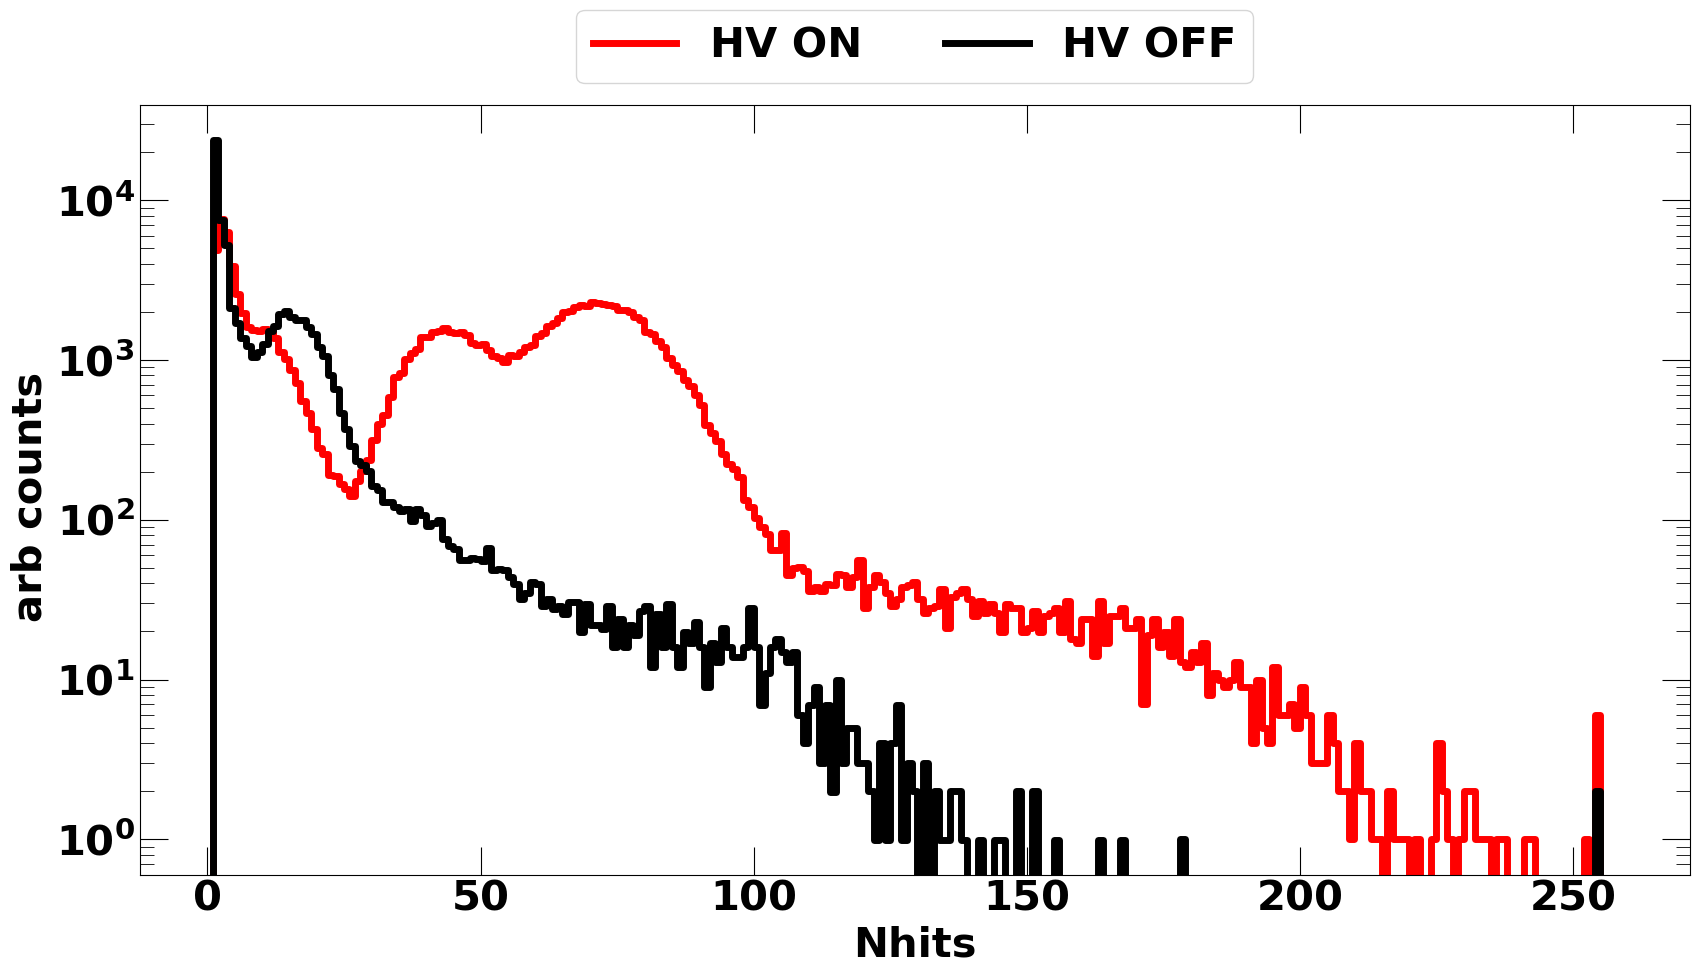

In [25]:
fig = plt.figure(1,figsize=(20,10))

bins = np.arange(0,260,1)

# All hits
all_hits, bins = np.histogram(big_df["Num_Hits"], bins=bins)

bin_centers = 0.5*(bins[1:] + bins[:-1])


y = all_hits / bin_centers

plt.step(bin_centers, y,
         where='mid',
         color='red',
         linewidth=5,
         label="HV ON")


# All hits
all_hits, bins = np.histogram(big_df_OFF["Num_Hits"], bins=bins)

bin_centers = 0.5*(bins[1:] + bins[:-1])


y = all_hits / bin_centers

plt.step(bin_centers, y,
         where='mid',
         color='black',
         linewidth=5,
         label="HV OFF")


plt.yscale("log")
plt.xlabel(r'Nhits', fontsize=30,fontweight='bold')
plt.ylabel('arb counts ', fontsize=30,fontweight='bold')
plt.tick_params(direction='in',which='minor',length=10,bottom=True, top =True, left=True, right=True)
plt.tick_params(direction='in',which='major',length=20,bottom=True, top =True, left=True, right=True)
plt.xticks(fontsize=30,fontweight='bold')
plt.yticks(fontsize=30,fontweight='bold')

plt.legend(prop={'weight':"bold", 'size':30},
           loc='upper center', ncol=5,
           bbox_to_anchor=(0.5, 1.15))

In [12]:
big_df[big_df["CH_Id"]==42]

,TStamp_us,Board_Id,Num_Hits,CH_Id,DataType,ToA_LSB,ToT_LSB,t_abs_us,Ring,Event_Id
52,5.125953e+03,1,64,42,48,39995,36,5.145950e+03,5,51
113,1.512637e+04,1,72,42,48,32581,36,1.514266e+04,5,109
143,2.512680e+04,1,60,42,48,6523,37,2.513006e+04,5,139
154,2.512680e+04,1,60,42,48,15543,43,2.513457e+04,5,149
215,3.512722e+04,1,75,42,48,15766,33,3.513511e+04,5,209
...,...,...,...,...,...,...,...,...,...,...
2140024,2.999676e+08,1,73,42,48,21426,36,2.999676e+08,5,2065234
2140047,2.999676e+08,1,73,42,48,36052,36,2.999676e+08,5,2065256
2140051,2.999676e+08,1,73,42,48,38327,31,2.999676e+08,5,2065260
2140137,2.999876e+08,1,85,42,48,2227,32,2.999876e+08,5,2065342


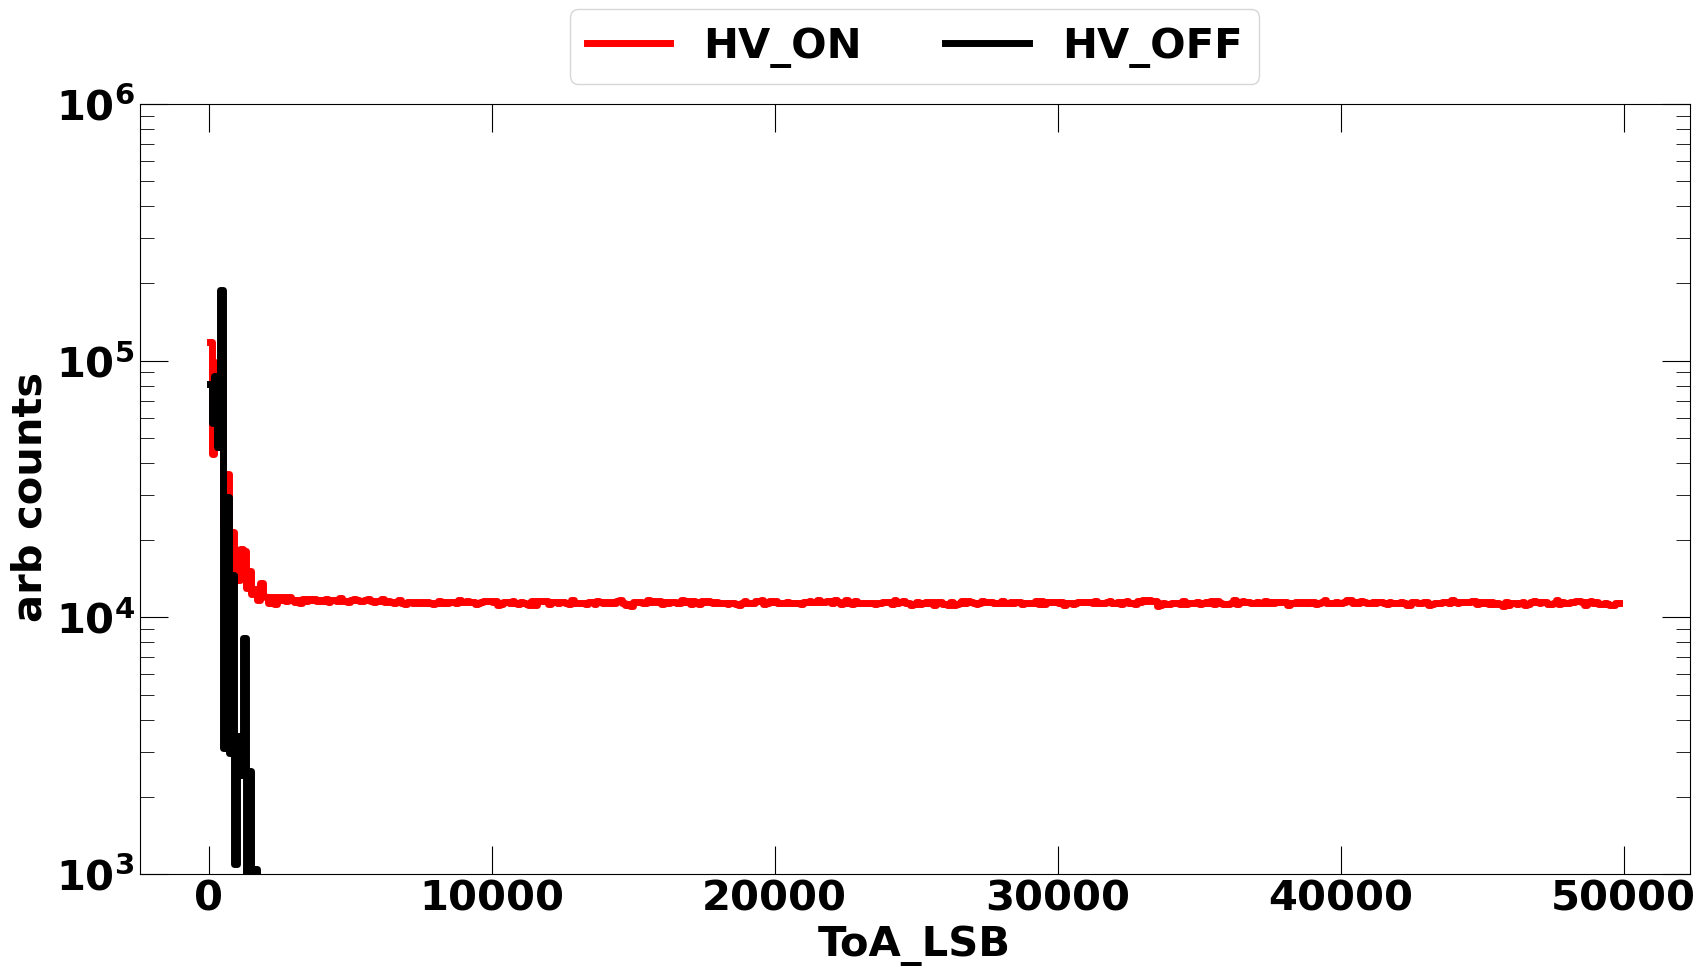

In [26]:
fig = plt.figure(1,figsize=(20,10))

bins = np.arange(0,50000,100)

# All hits
all_hits, bins = np.histogram(big_df["ToA_LSB"], bins=bins)

bin_centers = 0.5*(bins[1:] + bins[:-1])


y = all_hits

plt.step(bin_centers, y,
         where='mid',
         color='red',
         linewidth=5,
         label="HV_ON")



# All hits
all_hits, bins = np.histogram(big_df_OFF["ToA_LSB"], bins=bins)

bin_centers = 0.5*(bins[1:] + bins[:-1])


y = all_hits

plt.step(bin_centers, y,
         where='mid',
         color='black',
         linewidth=5,
         label="HV_OFF")
  

plt.yscale("log")

plt.ylim(1e3,1000e3)
plt.xlabel(r'ToA_LSB', fontsize=30,fontweight='bold')
plt.ylabel('arb counts ', fontsize=30,fontweight='bold')
plt.tick_params(direction='in',which='minor',length=10,bottom=True, top =True, left=True, right=True)
plt.tick_params(direction='in',which='major',length=20,bottom=True, top =True, left=True, right=True)
plt.xticks(fontsize=30,fontweight='bold')
plt.yticks(fontsize=30,fontweight='bold')

plt.legend(prop={'weight':"bold", 'size':30},
           loc='upper center', ncol=5,
           bbox_to_anchor=(0.5, 1.15))

In [29]:
bins[1]-bins[0]

100

In [38]:
all_hits

array([162015, 540222, 168807, 166821,   4389,    295,    160,     39,
           38,     14,     18,     34,     31,     44,     16,     18,
           23,     46,     19,      4,     18,     11,      6,     19,
           13,     30,     38,     25,     28,      8,     18,     29,
           10,     10,      8,     20,     14,     22,     27,     43,
           16,     30,     18,     12,     10,     18,     25,     18,
           19,     13,     12,     26,     18,     15,     14,     18,
           23,     31,      5,     12,     17,     19,     24,     21,
           21,     24,     24,     11,      6,     16,     27,     16,
           13,      8,     14,     12,     24,     20,     37,     28,
           20,     32,     17,     19,     20,     11,     16,     17,
           20,     23,     33,     20,     27,     18,      9,     14,
           29,     31,     13,     22,     23,     31,     18,     25,
            7,     15,     40,     31,     16,     20,     13,     25,
      